# Case Study: Ammonia Industry Transformation in Europe under Uncertainty

In this notebook we present the case study of the transformation of the European Ammonia industry under uncertainty using Chance Constrained Life Cycle Optimization (CC-LCO)

In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
import pandas as pd
import numpy as np
sys.path.append('..')
from pulpo import pulpo
from pulpo.utils.uncertainty import preparer, processor, plots, gsa
from pulpo.utils import optimizer, saver

## 0. Setup Background and Foreground Databases

### 0.1: Background Database (Ecoinvent 3.10 cutoff)

In [ ]:
from pathlib import Path
import bw2data as bd
import bw2io as bi

PROJECT = "ammonia_final"
DB_NAME = "ecoinvent-3.10-cutoff"
CRED_PATH = Path("/Users/hausslingbhl/Library/CloudStorage/OneDrive-UniversiteitLeiden/01_Administration/02_VITO/04_Systems/credentials.txt")

def read_credentials(path: Path):
    if not path.is_file():
        raise FileNotFoundError(f"Couldn't find credentials file at: {path.resolve()}")
    creds = {}
    for raw in path.read_text().splitlines():
        line = raw.strip()
        if not line or line.startswith("#"):
            continue
        # allow "key=value" or "key: value" or "key value"
        for sep in ("=", ":", " "):
            if sep in line:
                k, v = line.split(sep, 1)
                creds[k.strip().lower()] = v.strip()
                break
    if "username" not in creds or "password" not in creds:
        raise ValueError("credentials.txt must contain 'username' and 'password'.")
    return creds["username"], creds["password"]

# 1) Ensure project exists / is selected
bd.projects.set_current(PROJECT)

# 2) Import ecoinvent 3.10 cutoff if missing
if DB_NAME in bd.databases:
    print(f"Database '{DB_NAME}' already exists in project '{bd.projects.current}'.")
else:
    username, password = read_credentials(CRED_PATH)
    bi.import_ecoinvent_release(
        version="3.10",
        system_model="cutoff",  # "cutoff", "apos", "consequential", or "EN15804"
        username=username,
        password=password,
    )
    print(f"Database '{DB_NAME}' installed successfully.")

### 0.2: Foreground Database (Ammonia Production)

In [ ]:
# Path to your Excel file
excel_path = r"data/ammonia.xlsx"
fg_db_name = "ammonia"

if fg_db_name in bd.databases:
    print(f"Database '{fg_db_name}' already exists in project '{bd.projects.current}'.")
else:
    # 1. Import the Excel file
    fg_db = bi.ExcelImporter(excel_path)

    # 2. Apply strategies to clean and prepare the data
    fg_db.apply_strategies()

    # 3. Match the foreground database to itself (for internal links)
    fg_db.match_database(fields=["name", "unit", "reference product", "location"])

    # 4. Match to ecoinvent technosphere (use your actual ecoinvent db name)
    fg_db.match_database(
        "ecoinvent-3.10-cutoff",
        fields=["name", "unit", "location", "reference product"]
    )

    # 5. Match to ecoinvent biosphere (biosphere db is usually auto-named, check with list(bd.databases))
    biosphere_db = [db for db in bd.databases if "biosphere" in db and "3.10" in db][0]
    fg_db.match_database(
        biosphere_db,
        fields=["name", "categories", "location"]
    )

    # 6. Check statistics (should have 0 unlinked exchanges)
    fg_db.statistics()

    # 7. Write the database to disk
    fg_db.write_database()
    print(f"Database '{fg_db_name}' installed successfully.")

### 0.3: Install premise for GWP characterization factors

**Note:** Before executing the next cell, make sure to install `premise` via:
```bash
pip install premise
```

This package is required for adding updated GWP characterization factors to the project.

In [ ]:

# Check if the IPCC 2021 method already exists before adding premise GWP
import bw2data as bd

target_method = ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')

if target_method in bd.methods:
    print(f"Method '{target_method}' already exists in the project.")
else:
    print(f"Method '{target_method}' not found. Adding premise GWP characterization factors...")
    from premise_gwp import add_premise_gwp
    add_premise_gwp()
    print("Premise GWP characterization factors added successfully.")

### 0.4: Install IPCC 2013 GWP method with uncertainty

This method has been obtained and adapted from: https://github.com/aleksandra-kim/gwp_uncertainties

In [243]:
from bw2io.package import BW2Package
import bw2data as bd

target_method = ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
bd.projects.set_current("ammonia_final")

if target_method in bd.methods:
    print(f"Method '{target_method}' already exists in the project.")
else:
    print(f"Method '{target_method}' not found. Importing IPCC 2013 GWP method with uncertainty...")
    BW2Package.import_file("data/ipcc_uncertain.bw2package")
    print("IPCC 2013 GWP with uncertainty characterization factors added successfully.")


Method '('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')' already exists in the project.


## 1. Case Study Setup: Ammonia Production System

In [2]:
def setup_ammonia_case_study():
    """
    Set up the ammonia production case study with PULPO configuration.
    
    Returns:
        tuple: (project, database, method, directory) configuration parameters
    """
    project = "ammonia_final"
    database = ["ecoinvent-3.10-cutoff", "ammonia"]
    method = "('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')"
    directory = "develop_tests"
    
    return project, database, method, directory

def create_pulpo_worker(project, database, method, directory):
    """
    Create and initialize a PULPO optimizer instance.
    
    Args:
        project (str): PULPO project name
        database (str): Database name
        method (str): LCIA method specification
        directory (str): Working directory path
        
    Returns:
        pulpo.PulpoOptimizer: Configured PULPO worker instance
    """
    # Create PulpoOptimizer instance
    pulpo_worker = pulpo.PulpoOptimizer(project, database, method, directory)
    pulpo_worker.intervention_matrix = "ecoinvent-3.10-biosphere"
    
    # Import LCI data
    pulpo_worker.get_lci_data()
    
    return pulpo_worker

def get_single_process(worker, query, prefer_locations=("RER", "Europe", "GLO")):
    """
    Deterministic process retrieval to avoid order issues.
    
    Args:
        worker: PULPO optimizer instance
        query (str): Process name query
        prefer_locations (tuple): Preferred locations in order of preference
        
    Returns:
        Process object from the database
    """
    matches = worker.retrieve_processes(processes=query)
    if not matches:
        raise ValueError(f"No process found for query: {query}")
    for loc in prefer_locations:
        for p in matches:
            if getattr(p, "location", None) == loc or loc in str(p):
                return p
    return sorted(matches, key=lambda x: str(x))[0]

def define_ammonia_problem(pulpo_worker):
    """
    Define the ammonia production optimization problem with streamlined configuration.
    
    Args:
        pulpo_worker: PULPO optimizer instance
        
    Returns:
        tuple: (choices, demand) for the optimization problem
    """
    # Choice definitions with capacities bound per-label
    choice_config = {
        "biogas": {
            "processes": [
                "anaerobic digestion of agricultural residues",
                "anaerobic digestion of sequential crop",
                "anaerobic digestion of animal manure",
            ],
            # 2030 EU-27 potentials from biomethane shares (38 bcm total; 24% ag, 21% sequential, 32% manure),
            # converted to raw biogas assuming ~57% CH₄ → 16.0 & 14.0 bcm & 21.3 bcm ≈ 1.60e10 & 1.40e10 & 2.13e10 m³/yr.
            "capacities": [1.60e10, 1.40e10, 2.13e10],
        },
        "biomethane": {
            "processes": [
                "upgrading water scrubbing (CCS)",
                "upgrading water scrubbing",
                "upgrading chemical scrubbing",
                "upgrading chemical scrubbing (CCS)",
            ],
            "capacities": [1e20, 1e20, 1e20, 1e20],
        },
        "methane": {
            "processes": ["market for methane fg", "market for biomethane"],
            "capacities": [1e20, 1e20],
        },
        "heat": {
            "processes": ["heat from methane", "heat from methane (CCS)", "heat from hydrogen"],
            "capacities": [1e20, 1e20, 1e20],
        },
        "hydrogen": {
            "processes": [
                "methane pyrolysis",
                "steam methane reforming",
                "steam methane reforming (CCS)",
                "plastics gasification",
                "plastics gasification (CCS)",
                "alkaline electrolysis",
                "PEM electrolysis",
            ],
            # Methane pyrolysis capped to 10,000 t H2/yr (= 1.0e7 kg/yr); others left high for now.
            # "capacities": [3.0e8, 1e20, 1e20, 1e20, 1e20, 1e20, 1e20],
            "capacities": [1e20, 1e20, 1e20, 1e20, 1e20, 1e20, 1e20],
        },
        "electricity": {
            "processes": [
                "grid electricity",
                # "wind onshore electricity",
            ],
            "capacities": [1e20],#, 5e10], # Placeholder cap for wind onshore
        },
        "ammonia": {
            "processes": [
                "steam reforming, integrated",
                "steam reforming, integrated (CCS)",
                "nitrogen + hydrogen",
            ],
            "capacities": [1e20, 1e20, 1e20],
        },
    }

    # Build choices with deterministic mapping
    choices = {}
    for category, cfg in choice_config.items():
        labels, caps = cfg["processes"], cfg["capacities"]
        if len(labels) != len(caps):
            raise ValueError(f"Length mismatch in '{category}': {len(labels)} labels vs {len(caps)} capacities")
        choices[category] = {get_single_process(pulpo_worker, lbl): cap for lbl, cap in zip(labels, caps)}

    # Demand (EU ammonia, kg/yr)
    demand_process = get_single_process(pulpo_worker, "market for ammonia")
    demand = {demand_process: 17.1e9}  # ~17.1 Mt/yr (EU)

    # Additional upper bounds (shared resources / feedstocks)
    waste_pp = get_single_process(pulpo_worker, "treatment of waste PP")
    waste_ps = get_single_process(pulpo_worker, "treatment of waste PS")
    ccs_process = get_single_process(pulpo_worker, "CCS 200km pipeline 1000m deep")

    upper_bounds = {
        waste_pp: 1e20,#1.875e9,  # 25% of ~7.5 Mt PP post-consumer waste ≈ 1.875 Mt/yr
        waste_ps: 1e20,#3.25e8,   # 25% of ~1.3 Mt PS waste ≈ 0.325 Mt/yr
        ccs_process: 1e20,#5.0e9, # 5 MtCO2/yr (10% of EU-27 2030 NZIA target)
    }
    
    # Instantiate the optimization problem
    pulpo_worker.instantiate(demand=demand, choices=choices, upper_limit=upper_bounds)
    
    return choices, demand

def solve_and_summarize(pulpo_worker, file_name='ammonia_results'):
    """
    Solve the optimization problem and summarize results.
    
    Args:
        pulpo_worker: PULPO optimizer instance
        file_name (str): Filename for results (optional)
        
    Returns:
        dict: Extracted results data
    """
    # Solve optimization problem
    pulpo_worker.solve()
    
    # Extract and summarize results
    result_data = pulpo_worker.extract_results()
    pulpo_worker.summarize_results(zeroes=True)
    
    return result_data

In [3]:
# Set up the ammonia case study
project, database, method, directory = setup_ammonia_case_study()

# Create and initialize PULPO worker
pulpo_worker = create_pulpo_worker(project, database, method, directory)

# Define the optimization problem
choices, demand = define_ammonia_problem(pulpo_worker)

# Solve the problem and get results
# result_data = solve_and_summarize(pulpo_worker, file_name='ammonia_test')

print(f"✅ Setup complete: {sum(len(c) for c in choices.values())} alternatives across {len(choices)} categories")

Creating Instance
Instance created
✅ Setup complete: 23 alternatives across 7 categories


# Integrating epistemic uncertainty factors

**Next steps (7.1.2025)**
- [x] Agree on the iteration steps 
- [x] Agree on epistemic uncertainty factors and implementation as probability distributions
- [x] Decide which steps and uncertainty factors to focus on for the paper
- [x] Decide on if we want to include GSA in the result section
- Add literature to the uncertainty factors and quantification and refine it accordingly 
- Decide on what should go into the appendix/Suplementary material

Recompute the PULPO worker

In [4]:
# Set up the ammonia case study
project, database, method, directory = setup_ammonia_case_study()
# Create and initialize PULPO worker
pulpo_worker = create_pulpo_worker(project, database, method, directory)
# Define the optimization problem
choices, demand = define_ammonia_problem(pulpo_worker)

Creating Instance
Instance created


### Changes in the ammonia database done while refining case study
- Added 0.05 kg 'Carbon dioxide, non-fossil' in 'CCS 200km pipeline 1000m deep' (5% leakage)
- Changed "electricity, high voltage	grid electricity	RER	kilowatt hour	('ammonia', '49891e5d8da5e6cf0264c313f6a66376_copy1')" to be the aggregated activity of the ecoinvent version with the 10 most contributing biosphere flows. Then multiplying with 0.25, which represents a 75% decarbonized electricity mix. These biosphere flows are then used to add triag distribution 


## 1.(0.it.) System wide Epistemic Uncertainty 

### 1.1. Analyzing system wide epistemic uncertainty factors

System wide epistemic factors:
-	Intrinsic factors (directly linked to the technology/product): 
    - Infrastrucutre changes: The dominant epistemic uncertainty when looking at the transformation of the ammonia system from different feedstocks and upgrading technologies, are the immense infrastructure changes needed, anaerobic plants, pipelines (CO2, CH4), collection and transport of biomass (manure, crop residue and cover crops) and waste, CO2 storages, Complete new plants and supply chains when moving to more regionalized Hydrogen produciton ans small scale Ammonia production using electrification or small SMR plants.
    - Efficiency of prospective technologies will become more similar to the incumbent technologies
-	Indirect factors (system interactions): 
    - displacement of incumbent technologies: Major uncertainties linked to the fact that the incumbent technologies need to be fully replaced, depending on the pathway this is differently uncertainty, keeping biogas would allow to continue using integrated HB and SMR plants, while moving towards hydrogen from electrification or gasification of waste (plastic) would require new delocalized plants, which would increase the stability of NH3 produciton and allow adaption to localized needs and feedstocks, but requires substatial infrastructure chane
-	External factors (contextual): exogenous system shocks, policy/regulatory developments, macroeconomic dynamics.
    - Though relevant similar for the systems.

### 1.2. Implementing system wide epistemic uncertainty factors
In a first step the uncertainty data is included from the databases und using gap filling methods and literature data. The gap filling methods represent assumptions on the transformation related to epistemic uncertainty.

Gap filling methods for the IFs and CFs:

- Triangular interpolation for EcoInvent intervetion flows (Biosphere parameters)
    - Assuming that the underlying uncertainties across technologies is similar and can in its most simple interpolation be assessed from the bounds (95% confidence interval)
    - The epistemic transformational assumption is that the uncertainties of the incumbent technologies will have a similar epistemic uncertainties as they are modelled now and as they would be modelled for a future system.
- Triangular bounds specified for the forground database, i.e., the prospective technologies, they are chosen to be the same as the EcoInvent interpolated bounds (0.5 lower bound 0.95 upper bound)
    - At the starting point there are no probability distributions specified for the prospective system
    - The epistemic transformational assumption is that the epistemic uncertainties to which the incumbent system is subjected to, prospective technologies would be subjected to in the same fashion, i.e., that the "known unknowns" have a similar numeric extent, represented by the bounds of triangular distribution, assuming there to be a central moment larger than the bounds.
- Add Triangular distribution to CFs of GWP from Chen et al. 2021 assuming 10-20% variation of GWP results based on applying different LCIA methods
    - At the starting point there are no probability distribution specified for the characterization factors
    - Base uncertainty taken from: Chen et al. 2021 assuming 10-20% variation of GWP results based on applying different LCIA methods
    - The epistemic transformational assumption is that at a future state the uncertainties underlying the characterization factors which for GWP represent the impact pathway, accumulation etc. will due to the current feedback loops leading to a acceleration of GWP, therefore the upper bound is increased from 15% of the deterministic value from Chen et al. (2021) to 25%

In [5]:
pulpo_worker.import_and_filter_uncertainty_data(
    cutoff=0.,
    scaling_vector_strategy='constructed_demand',
    plot_results=False,
    plot_n_top_processes=19,
)

chosen environmental impact method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
The total impact is: 4.492359e+01
Characterized inventory: (2648, 23569) 21756
Filtered characterized inventory: (2648, 23569) 21756
Deviation from LCA score: 0.0
inventory (2648, 23569) filtering resulted in 21756 of 21756 exchanges (100.0% of total impact) and took 1.488 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 83 of 92 characterization factors
Intervention flows:
In ecoinvent-3.10-cutoff:
Parameters with uncertainty information: 16142 
Parameters without uncertainty information: 5557
In ammonia:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 57
Charactetization factors:
Parameters with uncertainty information: 32 
Parameters without uncertainty information: 52
Variable bounds:
Upper bound from choices without uncertainty information: 23
Upper bound from `upper_limit` without uncertainty information: 3
Low

In [6]:
unc_strategies = [
    processor.TriangularBoundInterpolationStrategy(
        uncertain_param_type='If',
        uncertain_param_subgroup='ecoinvent-3.10-cutoff',
        noise_interval={'min':.1, 'max':.1}
    ),

    processor.TriangluarBaseStrategy( # Assuming that the Foreground uncertainties are similar to the background ones
        uncertain_param_type='If',
        uncertain_param_subgroup='ammonia',
        upper_scaling_factor = 0.95, # The same as from TriangularBoundInterpolationStrategy of EcoInvent
        lower_scaling_factor = .5, # The same as from TriangularBoundInterpolationStrategy of EcoInvent
        noise_interval={'min':.1, 'max':.1}
    ),
    processor.TriangluarBaseStrategy( # Based on Chen et al. 2021 10-20% variation in CFs
        uncertain_param_type='Cf',
        uncertain_param_subgroup=method,
        upper_scaling_factor = 0.25,
        lower_scaling_factor = 0.15,
        noise_interval={'min':.05, 'max':.05},
        inverse_bounds_for_negative_values = False # This means that the skew is always towards zero, indepent if value is larger or smaller to zero
    )
    ]

In [7]:
pulpo_worker.apply_uncertainty_strategies(strategies=unc_strategies, plot_results=False)

Applying uncertainy strategy TriangularBoundInterpolationStrategy, for ecoinvent-3.10-cutoff in If
Computed spread statistics for 16142 uncertain parameters with defined uncertainty bounds.
upper spread statistics
geom: 0.4527 
mean: 1.8975
mode: 0    3.466758
Name: upper spread, dtype: float64
median: 0.9177
std: 8.2519
min: 0.0287
max: 786.9859


lower spread statistics
geom: 0.4527 
mean: 0.6272
mode: 0    0.776124
Name: lower spread, dtype: float64
median: 0.4786
std: 8.0129
min: 0.0279
max: 786.9859

After cleaning out outliers (z-score > 3), the spread statistics are:
upper spread statistics
geom: 0.4518 
mean: 1.7741
mode: 0    3.466758
Name: upper spread, dtype: float64
median: 0.9177
std: 1.8865
min: 0.0287
max: 24.2562


lower spread statistics
geom: 0.4518 
mean: 0.5141
mode: 0    0.776124
Name: lower spread, dtype: float64
median: 0.4786
std: 0.2953
min: 0.0279
max: 19.7686

The upper spread scaling factor for intervention flows is: 0.9177495253286797
The lower spread scali

### 1.3. Analyzing epistemic uncertainty factors

Analyze the Pareto front for the general epistemic system uncertainty

In [8]:
normal_metadata_env_cost, normal_metadata_var_bounds = pulpo_worker.create_CC_formulation(CC_env_cost=True)
lambda_epsilon_array = np.linspace(0.5,1, 5, endpoint=False)
results_CC_it0 = pulpo_worker.solve_CC_problem(lambda_epsilon_array, normal_metadata_env_cost, normal_metadata_var_bounds, plot_results=False)

No uncertainty data missing.
No uncertainty data missing.
Transforming If-ecoinvent-3.10-cutoff to normal distribution
21685 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
Transforming If-ammonia to normal distribution
57 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
Transforming Cf-('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain') to normal distribution
60 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
solving CC problem for lambda_QB = 0.5
Applying CC constraints to the environmental cost calculation with lambda: 0.5
Running HiGHS 1.8.0 (git hash: eda5cbe): Copyright (c) 2024 HiGHS under MIT licence terms
Cols:       47123 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Cols:       47123 upper bounds greater than or equal t

With a cutoff value of 0.05, we keep 3 process to an error of 60.41%
With a cutoff value of 0.05, we keep 3 process to an error of 90.03%
With a cutoff value of 0.05, we keep 3 process to an error of 162.44%
With a cutoff value of 0.05, we keep 3 process to an error of 793.99%
With a cutoff value of 0.05, we keep 3 process to an error of 231.55%
by grouping the processes by product, we reduce the number of variables to 5


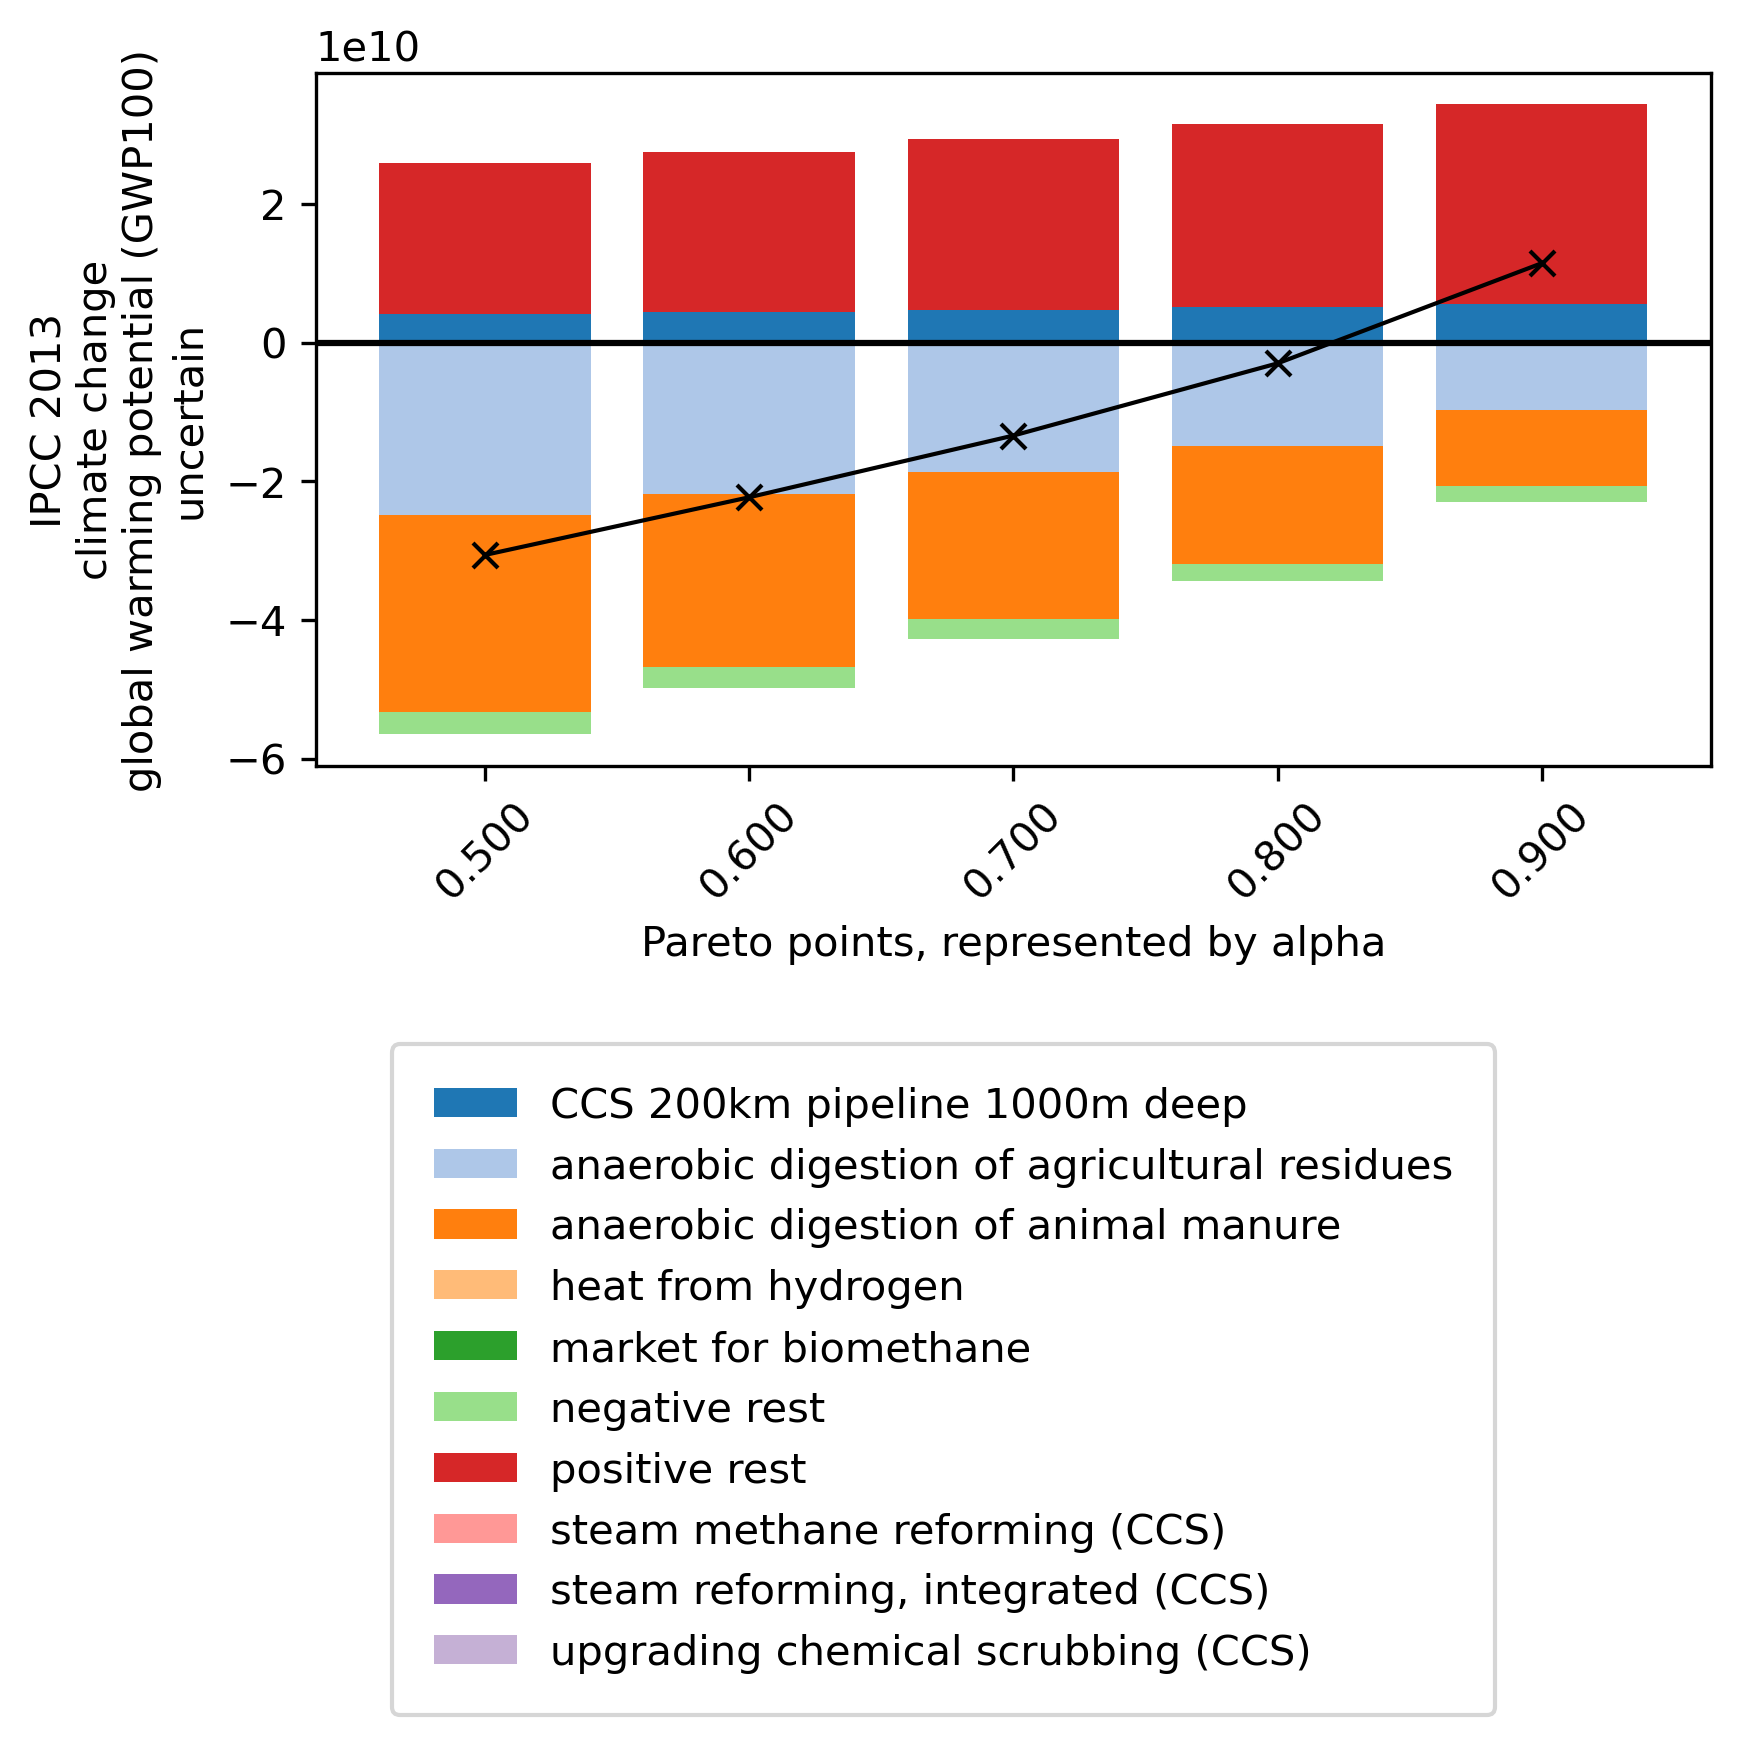

In [20]:
plots.plot_pareto_front(
    result_data_CC=results_CC_it0, 
    cutoff_value=0.05, 
    method="\n".join(method.split("'")[1::2]), 
    process_map_metadata=pulpo_worker.lci_data['process_map_metadata'], 
    bbox_to_anchor=(0.45,-1.4),
    cmap_name='tab20',
    group_act_by='process',
    include_choices=False
    )

#### 1.3.1. Analysis Outcome of Pareto front and technology shifts
- The negative impacts are driven by two processes (>90%), which describe the carbon content contained in the biomass (sequential crop and manure)
- While the positive impacts are driven by a wide range of processes
- Very strong dependency/sensitivity of the Pareto front on the variance linked to sequential crop and manure production
- The choices show that the biogas to **biomethane and SMR with CCS is used**. Based on this we can consider the following epistemic factors

### 1.4. Analyze Pareto Solutions with GSA

To understand what the driving parameters are the GSA of the relevant Pareto points is analyzed, to understand what epistemic uncertainties are relevant and how to include them

In [ ]:
from copy import deepcopy

In [ ]:
pulpo_worker_gsa = deepcopy(pulpo_worker)
pulpo_worker_gsa.import_and_filter_uncertainty_data(
    cutoff=0.000019, # removes processes to 1% impact contribution loss
    scaling_vector_strategy='naive',
    result_data=results_CC_it0[0.5],
    plot_results=False,
    plot_n_top_processes=19
)
pulpo_worker_gsa.apply_uncertainty_strategies(strategies=unc_strategies)

chosen environmental impact method: ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')
The total impact is: -2.777415e+10
Characterized inventory: (2648, 23569) 24586
Filtered characterized inventory: (2648, 23569) 826
Deviation from LCA score: 0.008114254864112214
inventory (2648, 23569) filtering resulted in 826 of 24586 exchanges (99.19% of total impact) and took 0.003 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 26 of 112 characterization factors
Intervention flows:
In ecoinvent-3.10-cutoff:
Parameters with uncertainty information: 735 
Parameters without uncertainty information: 71
In ammonia:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 20
Charactetization factors:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 26
Variable bounds:
Upper bound from choices without uncertainty information: 23
Upper bound from `upper_limit` without uncertainty information: 3
Lower boun

For one Pareto Point

No uncertainty data missing.
Var_bounds - upper_limit 
 	 26 parameters without uncertainty information
Define the GSA problem...
problem includes:
826 uncertain intervention flows
26 uncertain characterization factors
Sample the GSA problem...


/Users/hausslingbhl/Library/CloudStorage/OneDrive-UniversiteitLeiden/13_Code/03_Chapter_3/pulpo_flechtenberg/pulpo/notebooks/../pulpo/utils/uncertainty/gsa.py:92: UserWarning: The uncertainty data contains undefined uncertainty types. Please define all uncertainty types before running the GSA.
  warnings.warn("The uncertainty data contains undefined uncertainty types. Please define all uncertainty types before running the GSA.")
/Users/hausslingbhl/miniconda3/envs/pulpo_dev/lib/python3.10/site-packages/scipy/stats/_qmc.py:993: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


Run the model for all samples...
The statistics of the the sample impacts: ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')
count    1.706000e+05
mean    -2.645508e+10
std      2.296932e+10
min     -9.939216e+10
25%     -4.302541e+10
50%     -2.593678e+10
75%     -1.009721e+10
max      3.683482e+10
dtype: float64
The deterministic impact is 1.0 : -5.047919e+09
(170600,)
the z-value of the total impact: 0.8682382979662295
Analyze the GSA results...


/Users/hausslingbhl/miniconda3/envs/pulpo_dev/lib/python3.10/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


The total explained variance is 
105.8%
Plot the GSA results...


(                      ST       ST_conf
 (80, 557)   4.502381e-08  1.580134e-08
 (80, 818)   1.255296e-08  3.934563e-09
 (80, 868)   1.286111e-10  3.233838e-11
 (80, 1070)  3.930170e-07  1.150153e-07
 (80, 1363)  2.545923e-09  8.742296e-10
 ...                  ...           ...
 2129        3.838474e-06  1.316594e-06
 2341        1.125925e-06  3.511714e-07
 2514        5.075063e-08  1.586030e-08
 2515        7.536871e-07  2.592508e-07
 2517        1.820141e-07  6.382381e-08
 
 [852 rows x 2 columns],
 {'S1': array([ 1.95947162e-05,  3.28936400e-05, -3.99435859e-06,  7.94855643e-05,
         -3.59990878e-06, -1.06255968e-06, -9.94502953e-06,  1.02491746e-06,
         -1.87226659e-04,  2.01024408e-03, -5.50506167e-06,  7.30119871e-05,
         -3.44833971e-08,  8.90525176e-07,  8.03579557e-07, -8.86458099e-05,
         -1.00737161e-08, -7.07183582e-07, -4.25070733e-07, -2.37904609e-06,
          1.83816932e-04,  3.13242011e-07, -1.22129401e-05,  1.08909345e-06,
         -3.70606676e-06,

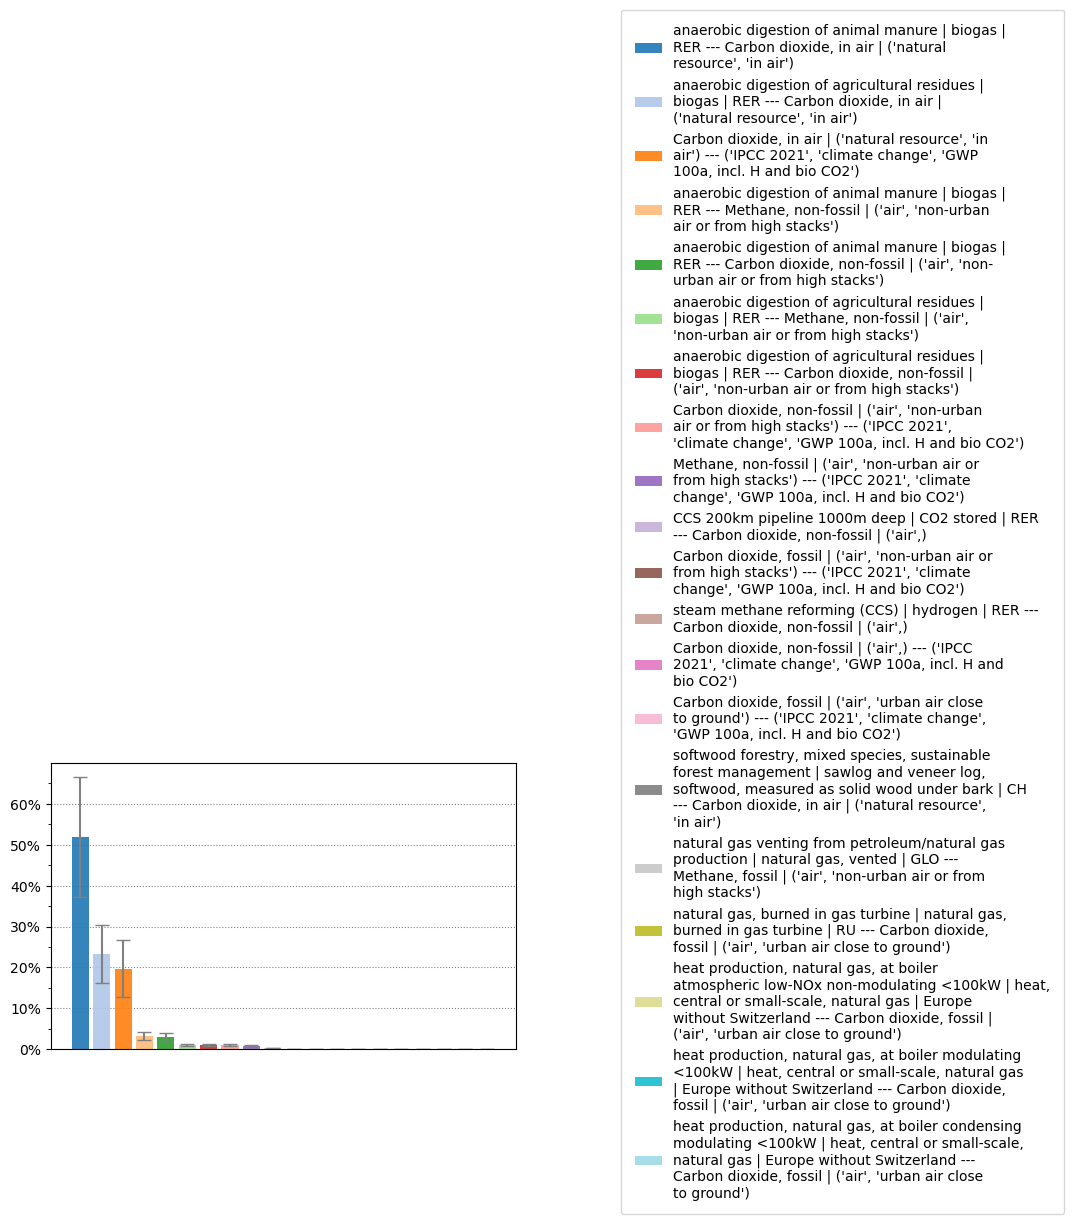

In [ ]:
from SALib.sample import sobol as sample_method
from SALib.analyze import sobol as SA_method
pulpo_worker_gsa.run_gsa(
    result_data=results_CC_it0[0.5],
    sample_method=sample_method,
    SA_method=SA_method,
    sample_size=100,
    plot_gsa_results=True,
    top_sensitivity_amt=20
)

For all Pareto Points

In [ ]:
from SALib.sample import sobol as sample_method
from SALib.analyze import sobol as SA_method
for lambda_level, results_CC_level in results_CC_it1.items():
    print(f'Running GSA for lambda = {lambda_level}')
    pulpo_worker_gsa.import_and_filter_uncertainty_data(
        cutoff=0.000019, # removes processes to 1% impact contribution loss
        scaling_vector_strategy='naive',
        result_data=results_CC_level,
        plot_results=False,
        plot_n_top_processes=19
    )
    pulpo_worker_gsa.apply_uncertainty_strategies(strategies=unc_strategies)
    pulpo_worker_gsa.run_gsa(
        result_data=results_CC_level,
        sample_method=sample_method,
        SA_method=SA_method,
        sample_size=10,
        plot_gsa_results=True
    )

#### 1.4.1. Analysis outcome of GSA

The main contributing parameters are:

???


## 2. (1.it.) Epistemic uncertainty of Biomass to Bio methanol (bounds and objective)

Hook: From the first epistemic uncertainty integration, the Pareto front shows a strong dependency on the biomass to biogas activities and their underlying uncertainties, due to the strong slope of the Pareto front.


### 2.1. Analyzing epistemic uncertainty factors

#### 2.1.1. Related to Biomass CO2 Uptake

Beyond the base epistemic uncertainty, epistemic uncertainty related to transformation is considered, these factors relate directly to the underlying transformation problem and might lead to distributions being updated or novel parameters introduced.

Indirect factors:
 - allocation factors and functional changes: 
    - Allocation factors have substatial relevance when fundamental changes occure, as it can shift how agriculture is done
    - **Manure CO2 uptake as the most sensitive shows the role of anuimal manure, while animal manure is a by-product of mainly meat and dairy industry, these industries are the drivers for land-use and deforestation, both directly and indirectly from the feed (soy), meaning that the manure can not be carbon negative, as it is related to a net carbon positive activity.**
    - if the former by-products become lucarative, leading to environmental destructive technologies and production system, e.g., intensive feedstock for meat production (using imported feed instead of circular crop-residue to feed routes), to remain feasible as their byproducts, manure, becoming a more valuable resource (thereby lifting direct loval environmental limits, due to Nitrogen surplus or GHG emissions from manure treatment, but still not reducing direct emissions and land-use, thereby strengtening the lock-in)
    - extracting crop residue or cover crops, which are meant to keep local nutrient loops closed, e.g., by taking up surplus nutrients and organically binding them for the next harvest (cover crops) 
    - increasing the Hummus of the soil by shredding and tilling the crop-residue, which is an important carbon sequestrential technique and by extracting it, it reduced the potential for system wide CO2 offsetting. 
    - When the positive environmental impacts linked to these practices are ignored and not weighted into the system and the impacts of the interlinked products, e.g., meat are not related to the feedstock.

3 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation


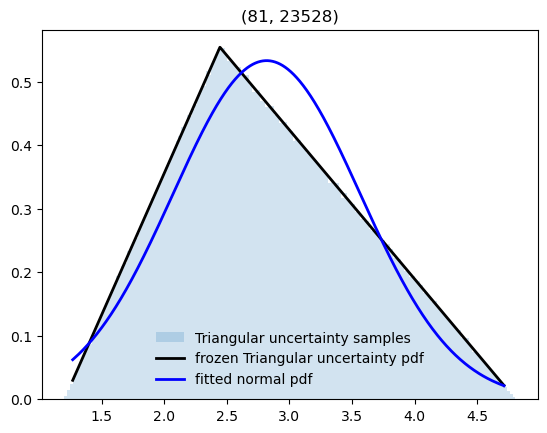

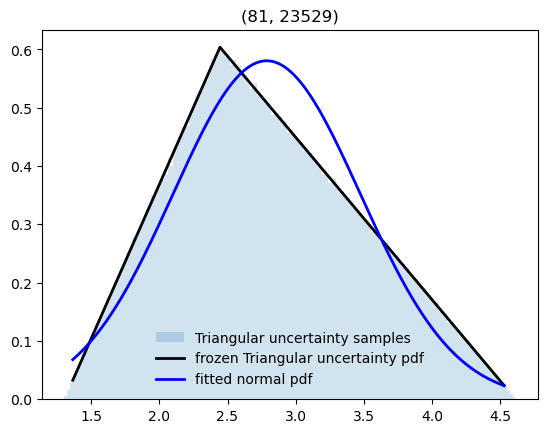

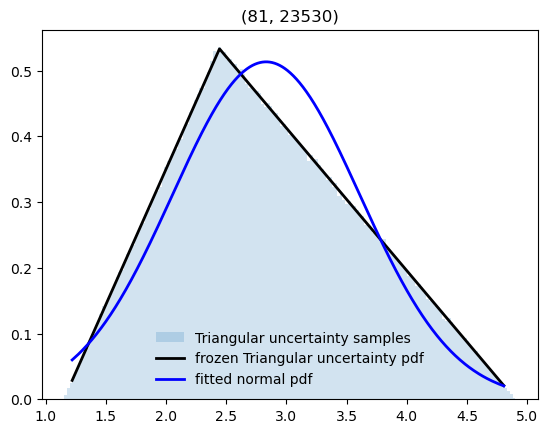

{(81, 23528): {'scale': 0.7479727835454205,
  'loc': 2.8176900119361523,
  'uncertainty_type': 3},
 (81, 23529): {'scale': 0.6873939995470466,
  'loc': 2.7873908166944705,
  'uncertainty_type': 3},
 (81, 23530): {'scale': 0.7772598162874852,
  'loc': 2.831792220937859,
  'uncertainty_type': 3}}

In [224]:
# Gets the descriptive names of the intervention flows for ammonia related processes
If_ammonia_unc = processor.rename_metadata_index(
    pd.DataFrame.from_records(pulpo_worker.uncertainty_data['If']['ammonia']['defined']).T, 
    pulpo_worker.lci_data, 
    'intervention_flow'
    )
# The intervention flows which might require special attention
If_names = [
    "anaerobic digestion of agricultural residues | biogas | RER --- Carbon dioxide, in air | ('natural resource', 'in air')",
    "anaerobic digestion of animal manure | biogas | RER --- Carbon dioxide, in air | ('natural resource', 'in air')",
    "anaerobic digestion of sequential crop | biogas | RER --- Carbon dioxide, in air | ('natural resource', 'in air')"
]
# Plotting the distributions of the selected intervention flows
matched_If_indcs = If_ammonia_unc.loc[If_names, 'index'].values
matched_If_unc_metadata = {indx:pulpo_worker.uncertainty_data['If']['ammonia']['defined'][indx] for indx in matched_If_indcs}
processor.fit_normals(matched_If_unc_metadata, plot_distributions=True, lci_data=pulpo_worker.lci_data)


#### 2.1.2. Related to Biomass (agriculture residues and sequential crops) as feedstock:
- Intrinsic factors: (directly linked to the technology/product): 
    - efficiency and functionality change: 
        - functional change: 
            - Depending on what biogas/methane is used for, e.g., hydrogen source, heating source and other competing chemical service functions it might be used for that instead, which might force production to use natural gas again.
    - resource criticality: Biomass will be required in many different areas beyond biogas and biogas/methane will be required for many other applications beyond industrial heating, Hydrogen source
- Indirect factors (system interactions): 
    - behavioural responses and rebound:
        - Biogas/methane will be required in many places which might lead to a switch back to natural gas, locking in on HB as the only way to produce NH3
    - supply chain effects: Moving to more organic production system or vegan diets, required to remain within ecological limits, will reduce the availability of second generation biomass
- _External factors_ (contextual): 
    - exogenous system shocks: 
        - natural desaster influencing biomass production and requiring more biomass to be used for food compared to feed, fuel.
        - wars and conflicts intervening into global food supply chains leading to more localized production (less residues available, more land-use, etc.) 
    - policy/regulatory developments: Shifting towards less intensive farming or organic farming
    - macroeconomic dynamics: crisis driving food and biomass prices up

In [ ]:
# Gets the descriptive names of the variable bounds for the biomass related processeses
var_bounds_unc = processor.rename_metadata_index(
    pd.DataFrame.from_records(pulpo_worker.uncertainty_data['Var_bounds']['upper_limit']['undefined']).T, 
    pulpo_worker.lci_data, 
    'process'
    )
display(var_bounds_unc)
# The intervention flows which might require special attention
process_names = [
    "anaerobic digestion of agricultural residues | biogas | RER ",
    "anaerobic digestion of animal manure | biogas | RER ",
    "anaerobic digestion of sequential crop | biogas | RER "
]
# Plotting the distributions of the selected intervention flows
matched_process_indcs = var_bounds_unc.loc[process_names, 'index'].values
var_bounds_unc = var_bounds_unc.drop(columns=['index'])
matched_varbound_unc_metadata = {indx:pulpo_worker.uncertainty_data['Var_bounds']['upper_limit']['undefined'][indx] for indx in matched_process_indcs}

,index,amount,uncertainty_type
index,,,
CCS 200km pipeline 1000m deep | CO2 stored | RER,23523,1.000000e+20,0.0
PEM electrolysis | hydrogen | RER,23524,1.000000e+20,0.0
alkaline electrolysis | hydrogen | RER,23526,1.000000e+20,0.0
anaerobic digestion of agricultural residues | biogas | RER,23528,1.600000e+10,0.0
anaerobic digestion of animal manure | biogas | RER,23529,2.130000e+10,0.0
anaerobic digestion of sequential crop | biogas | RER,23530,1.400000e+10,0.0
"grid electricity | electricity, high voltage | RER",23537,1.000000e+20,0.0
heat from hydrogen | heat | RER,23538,1.000000e+20,0.0
heat from methane | heat | RER,23539,1.000000e+20,0.0


### 2.2. Implementing the epistemic unvertainty factors


#### 2.2.1. For Biomass CO2 uptake

Due to the very relevant and overlapping epistemic uncertainties realted to biomass and the (deterministically  optimistic modelling of the biomass):
- not allocating any of the production activities to the wastes, 
    - even though the intense increase in the demand and valorization can have effect on the economic decisions how to farm. 
    - That ammonia through fertilizer is connected back to the same system, which means the multiple functions of activities can not be solved with allocation, as the by-products and main products relate to eachother again
- not accounting for the reduction in environmental stress, through sequestration and nutrient retention
- Decrease in organic CO2 offsetting potential, through sequenstration of cover crops, crops residue and manure by tilling and shredding
- not accounting for alternative feedback and circularity loops, e.g., Nitrogen in manure of protein cover crops, which provide the same function as ammonia for synthetic fertilizer
    - Additinoal to potential increase in ammonia demand through the loss of nutrients and nutrient preservation by organic farming methods.

That the CO2 taken up by the plant is exactly what is avialable at the bio-gas (anaerobic digestion step) can be understood as a carbon balance where all CO2 which is captured by the biomass at the field is made available at the anaerobic plant.

Shifting the probability distribution of the uncertaint parameters inversely as they are subjected to negative characterization factors, so their distribution should reflect that the upper bound (0.9) is for the lower bound, meaning that the distribution of the "CO2 uptake" is close to zero at its bound this is the result of, and the upper bound is (0.1) as it can not take up more CO2 than the stochastic maximum:
- biomass being lost on the way would translate into less CO2 being taken up assuming the same biomass amount
- applying substitution for the CO2 which would be captured if the biomass would remain on the field, translates into reduced CO2 uptake
- Farming of cover crops is difficult as yields are low and it would decrease soil fertility, requiring more fertilizers (Alterra, 2023, p. 24) 

3 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation


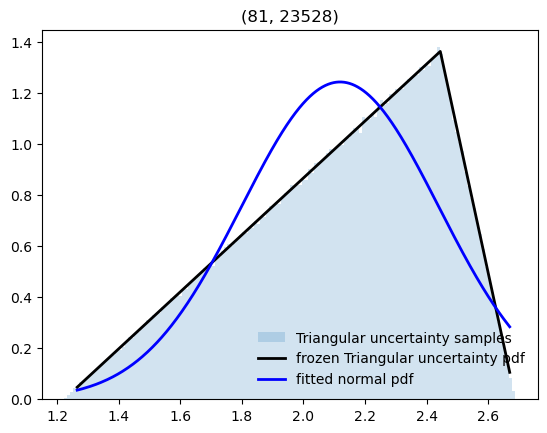

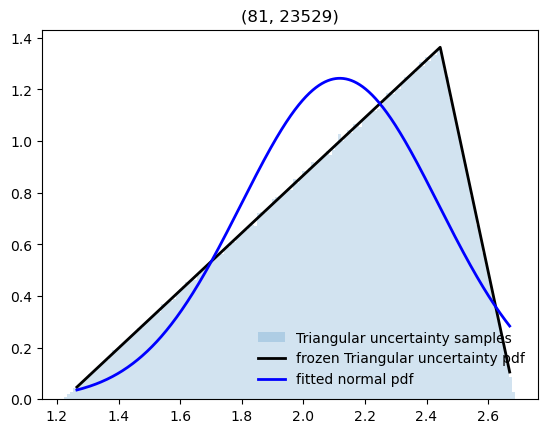

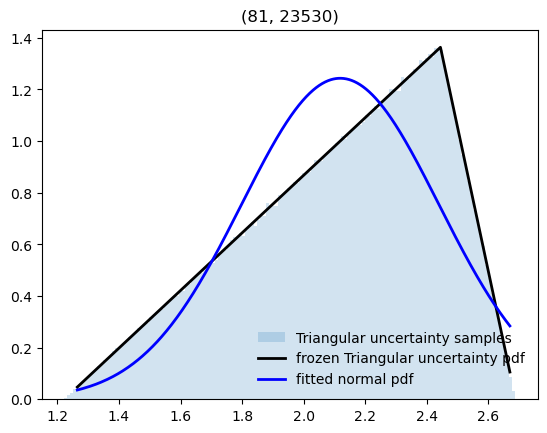

{(81, 23528): {'scale': 0.32074986824511753,
  'loc': 2.118916500446892,
  'uncertainty_type': 3},
 (81, 23529): {'scale': 0.32087911406494735,
  'loc': 2.118482624215983,
  'uncertainty_type': 3},
 (81, 23530): {'scale': 0.3208546124119269,
  'loc': 2.118797716387704,
  'uncertainty_type': 3}}

In [225]:
lower_scaling_factor = .5 #.9
upper_scaling_factor = .1
for indx, unc_metadata in matched_If_unc_metadata.items():
    matched_If_unc_metadata[indx]['minimum'] = unc_metadata['amount'] - unc_metadata['amount'] * lower_scaling_factor
    matched_If_unc_metadata[indx]['maximum'] = unc_metadata['amount'] + unc_metadata['amount'] * upper_scaling_factor
processor.fit_normals(matched_If_unc_metadata, plot_distributions=True, lci_data=pulpo_worker.lci_data)


In [226]:
epistemic_unc_strategies_iteration_1 = [processor.ExpertKnowledgeStrategy(
        uncertain_param_type='If',
        uncertain_param_subgroup='ammonia',
        prob_metadata=matched_If_unc_metadata
    )]
pulpo_worker.apply_uncertainty_strategies(strategies=epistemic_unc_strategies_iteration_1)

Applying uncertainy strategy ExpertKnowledgeStrategy, for ammonia in If
Var_bounds - upper_limit 
 	 26 parameters without uncertainty information


#### 2.2.2. For Biomass as feedstock

System wide epistemic uncertainty:
- resource criticality linked to availability and insecurity of biomass, due to growing conditions, environmental changes, increased demand due to multiple shifts from fossile to biomass not only for NH3, as also the case for waste

Updating the epistemic uncertainty factors
- All variable bounds of biomass 

Modelling the updated uncertain factors
- Adding/Updating variable bounds to the biomass availabilities
- Adding triangular probability distribution on the var bounds 

3 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation


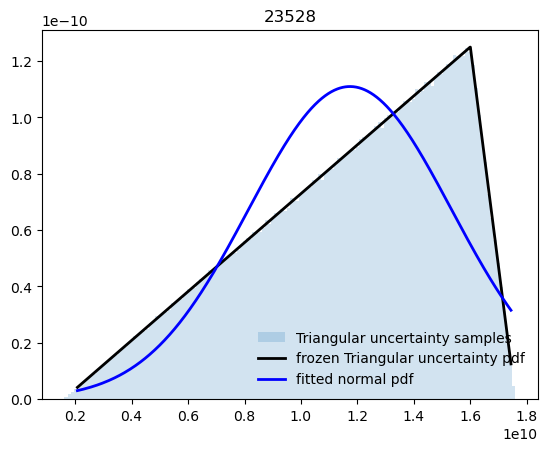

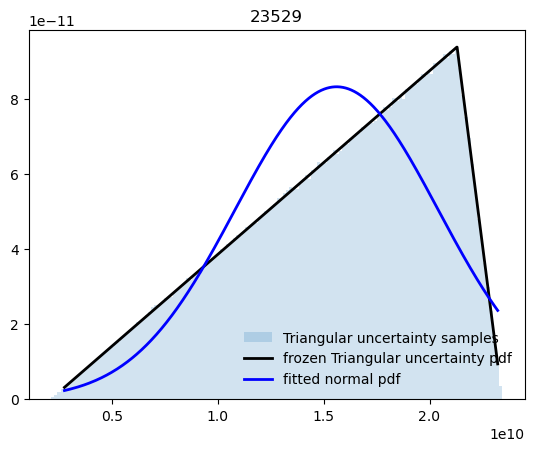

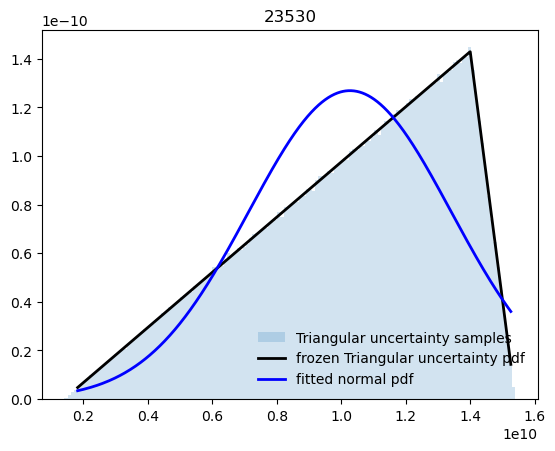

{23528: {'scale': 3595833584.9269433,
  'loc': 11736931759.485138,
  'uncertainty_type': 3},
 23529: {'scale': 4790648615.211501,
  'loc': 15614293458.993631,
  'uncertainty_type': 3},
 23530: {'scale': 3146156153.9637146,
  'loc': 10268050494.313581,
  'uncertainty_type': 3}}

In [ ]:
lower_multiplying_factor = .1
upper_multiplying_factor = 1.1
for indx, unc_metadata in matched_varbound_unc_metadata.items():
    matched_varbound_unc_metadata[indx]['minimum'] = unc_metadata['amount'] * lower_multiplying_factor
    matched_varbound_unc_metadata[indx]['maximum'] = unc_metadata['amount'] * upper_multiplying_factor
    matched_varbound_unc_metadata[indx]['loc'] = unc_metadata['amount']
    matched_varbound_unc_metadata[indx]['uncertainty_type'] = 5
processor.fit_normals(matched_varbound_unc_metadata, plot_distributions=True, lci_data=pulpo_worker.lci_data)

In [ ]:
epistemic_unc_strategies_iteration_var_bounds = [processor.ExpertKnowledgeStrategy(
        uncertain_param_type='Var_bounds',
        uncertain_param_subgroup='upper_limit',
        prob_metadata=matched_varbound_unc_metadata
    )]
pulpo_worker.apply_uncertainty_strategies(strategies=epistemic_unc_strategies_iteration_var_bounds)

Applying uncertainy strategy ExpertKnowledgeStrategy, for upper_limit in Var_bounds
Var_bounds - upper_limit 
 	 23 parameters without uncertainty information


For the remaining variable bounds, as they are not specified, there spread is set to almost zero (zero does not work).

In [ ]:
var_bound_strategy = [processor.TriangluarBaseStrategy(
    uncertain_param_type='Var_bounds',
    uncertain_param_subgroup='upper_limit',
    upper_scaling_factor=.001,
    lower_scaling_factor=.001,
    noise_interval={'min':.05, 'max':.05}
)]
pulpo_worker.apply_uncertainty_strategies(strategies=var_bound_strategy)

Applying uncertainy strategy TriangluarBaseStrategy, for upper_limit in Var_bounds
No uncertainty data missing.


### 2.3. Analyze Pareto front

The technological choices in transformation solution of the deterministic solution are:

In [ ]:
normal_metadata_env_cost, normal_metadata_var_bounds = pulpo_worker.create_CC_formulation(CC_env_cost=True, CC_var_bounds=['upper_limit'])

No uncertainty data missing.
No uncertainty data missing.
Transforming If-ecoinvent-3.10-cutoff to normal distribution
26555 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
Transforming If-ammonia to normal distribution
71 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
Transforming Cf-('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2') to normal distribution
100 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation


In [228]:
lambda_epsilon_array = np.linspace(0.5,1, 5, endpoint=False)
results_CC_it1 = pulpo_worker.solve_CC_problem(lambda_epsilon_array, normal_metadata_env_cost, normal_metadata_var_bounds, plot_results=False)

solving CC problem for lambda_QB = 0.5
Applying CC constraints to the environmental cost calculation with lambda: 0.5
Running HiGHS 1.8.0 (git hash: eda5cbe): Copyright (c) 2024 HiGHS under MIT licence terms
Cols:       47123 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Cols:       47123 upper bounds greater than or equal to        1e+20 are treated as +Infinity
Rows:       23546 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Rows:       23567 upper bounds greater than or equal to        1e+20 are treated as +Infinity
optimal solution found:  -5047919086.5212145
solving CC problem for lambda_QB = 0.6
Applying CC constraints to the environmental cost calculation with lambda: 0.6
Running HiGHS 1.8.0 (git hash: eda5cbe): Copyright (c) 2024 HiGHS under MIT licence terms
Cols:       47123 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Cols:       47123 upper bounds greater than or equal to        1e+20 

With a cutoff value of 0.03, we keep 4 process to an error of 350.30%
With a cutoff value of 0.03, we keep 4 process to an error of 3163.46%
With a cutoff value of 0.03, we keep 4 process to an error of 309.06%
With a cutoff value of 0.03, we keep 4 process to an error of 162.34%
With a cutoff value of 0.03, we keep 4 process to an error of 73.38%
by grouping the processes by product, we reduce the number of variables to 9


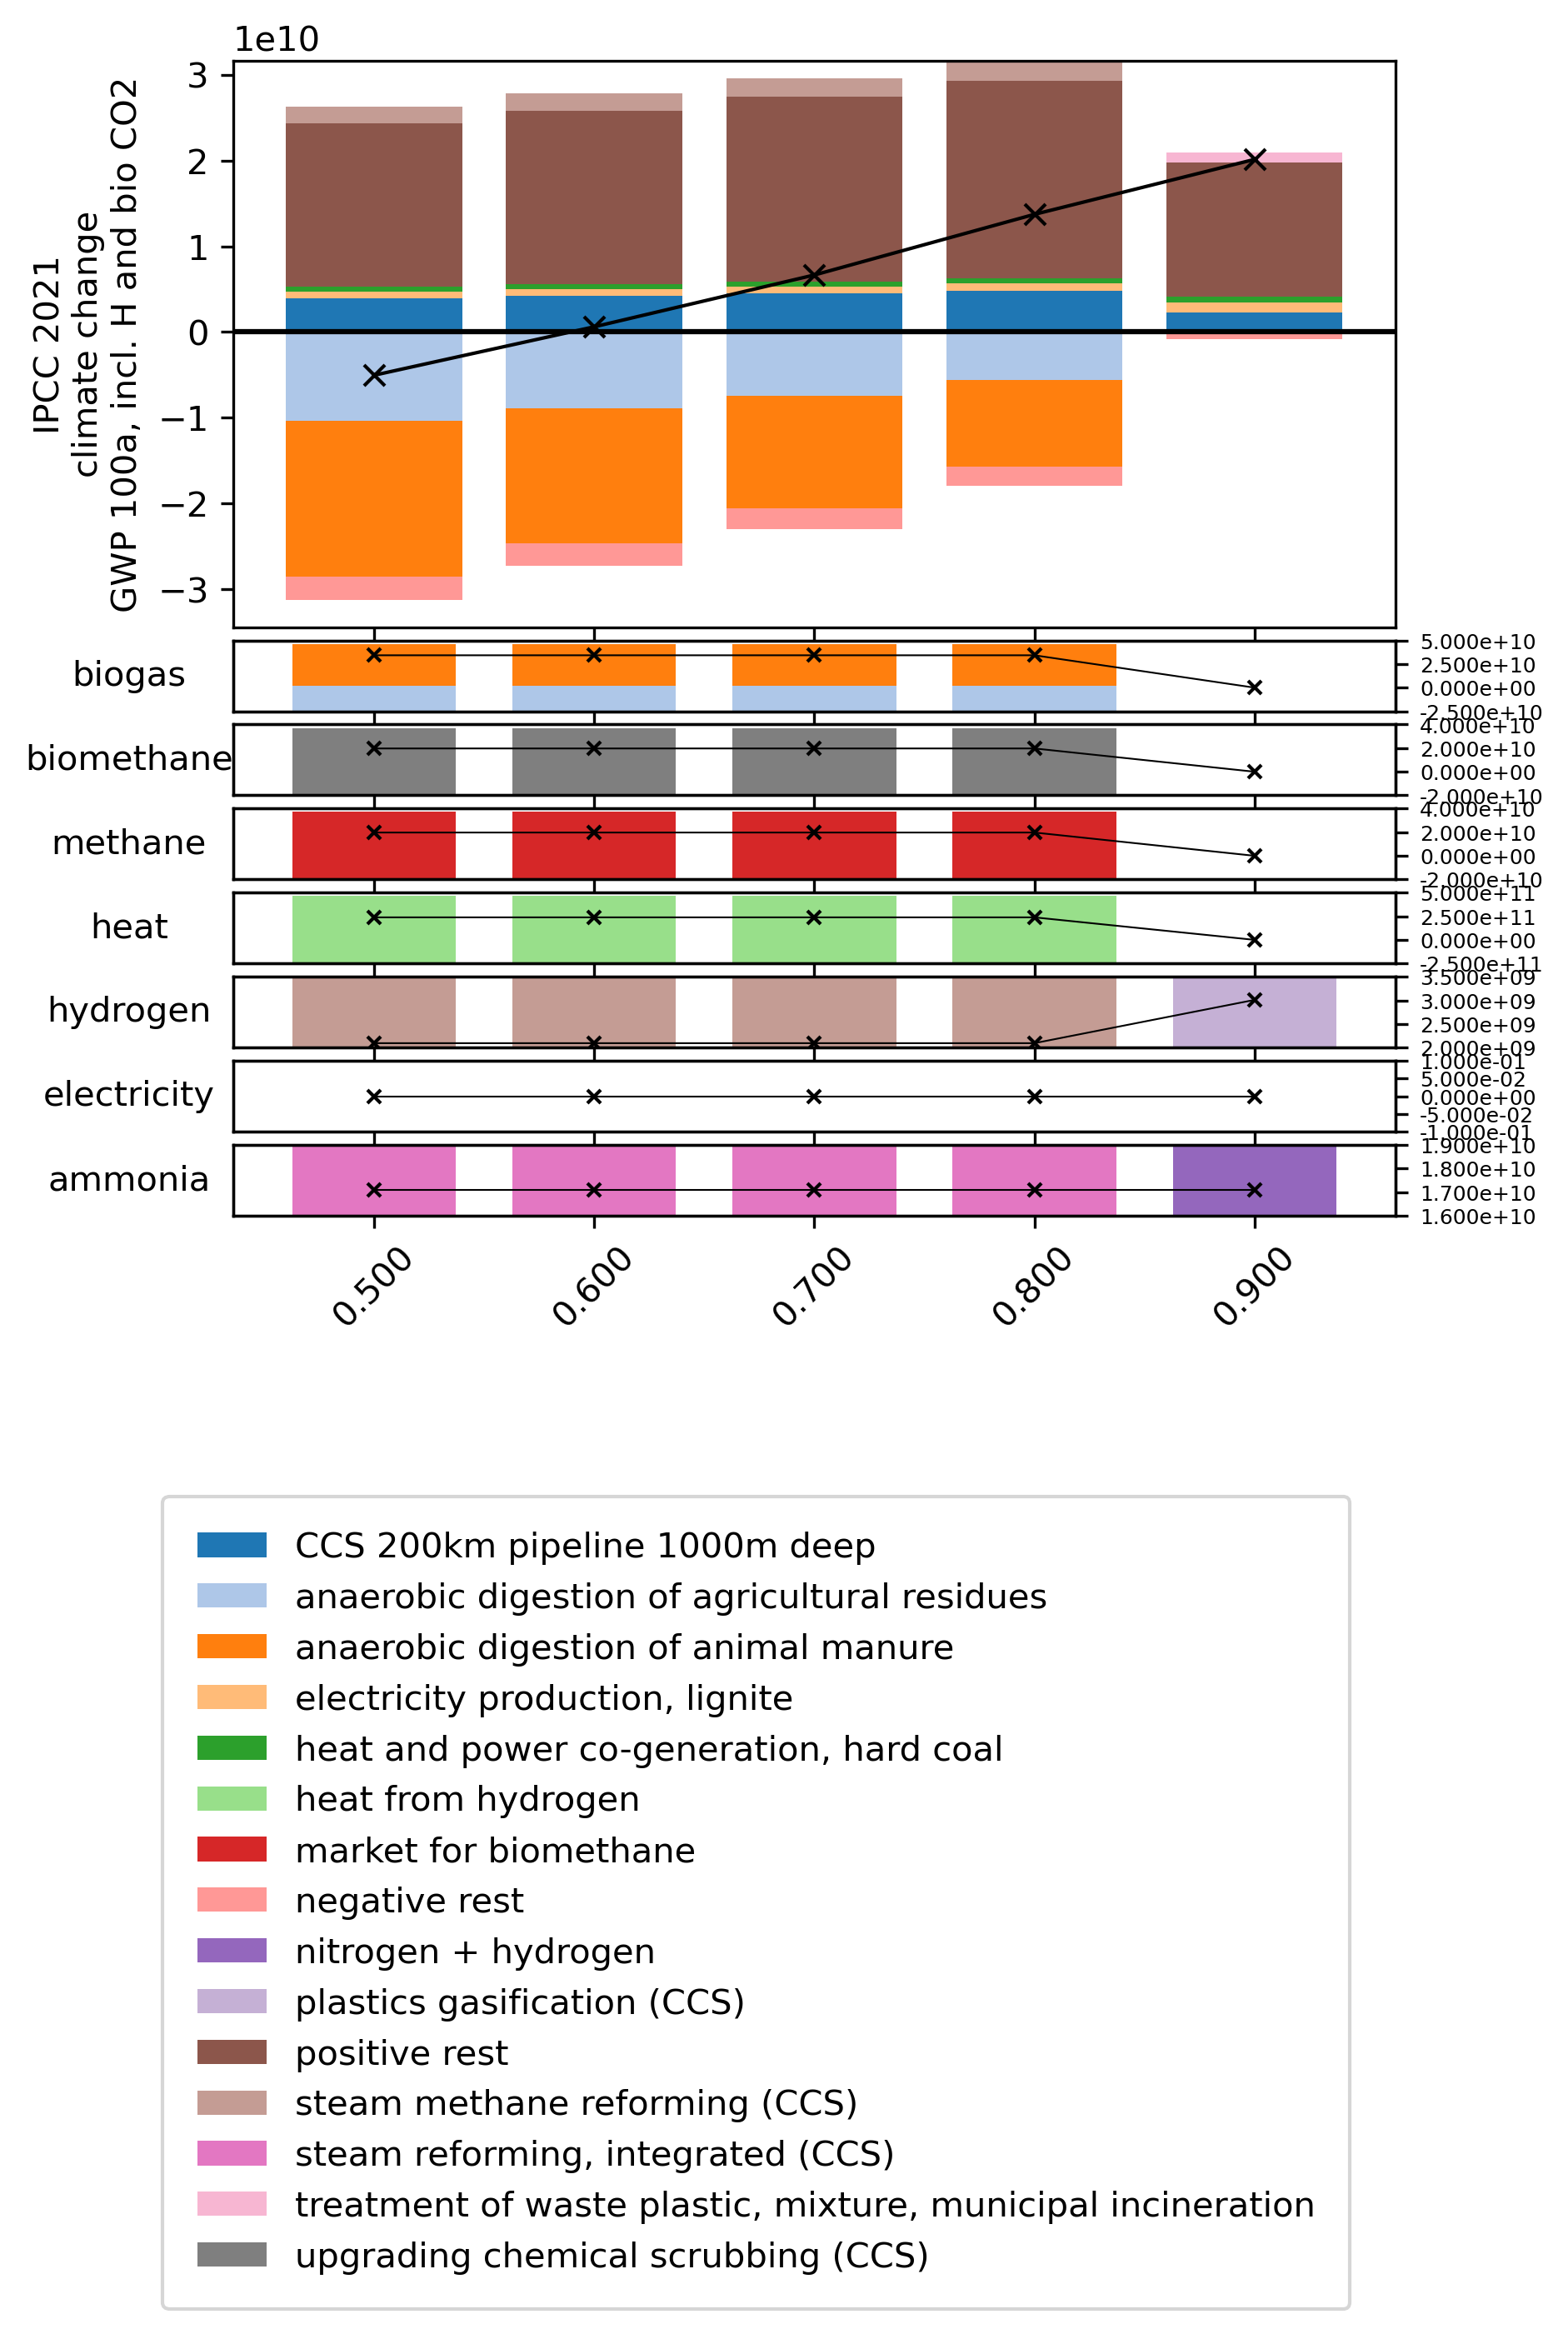

In [229]:
plots.plot_pareto_front(
    result_data_CC=results_CC_it1, 
    cutoff_value=0.03, 
    method="\n".join(method.split("'")[1::2]), 
    process_map_metadata=pulpo_worker.lci_data['process_map_metadata'], 
    bbox_to_anchor=(0.45,-3.),
    cmap_name='tab20',
    group_act_by='process'
    )

### 2.4. Analyze Pareto Solutions with GSA

To understand what the driving parameters are the GSA of the relevant Pareto points is analyzed, to understand what epistemic uncertainties are relevant and how to include them

In [234]:
from copy import deepcopy

In [236]:
pulpo_worker_gsa = deepcopy(pulpo_worker)
pulpo_worker_gsa.import_and_filter_uncertainty_data(
    cutoff=0.000019, # removes processes to 1% impact contribution loss
    scaling_vector_strategy='naive',
    result_data=results_CC_it1[0.5],
    plot_results=False,
    plot_n_top_processes=19
)
pulpo_worker_gsa.apply_uncertainty_strategies(strategies=unc_strategies)

chosen environmental impact method: ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')
The total impact is: -2.777415e+10
Characterized inventory: (2648, 23569) 24586
Filtered characterized inventory: (2648, 23569) 826
Deviation from LCA score: 0.008114254864112214
inventory (2648, 23569) filtering resulted in 826 of 24586 exchanges (99.19% of total impact) and took 0.003 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 26 of 112 characterization factors
Intervention flows:
In ecoinvent-3.10-cutoff:
Parameters with uncertainty information: 735 
Parameters without uncertainty information: 71
In ammonia:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 20
Charactetization factors:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 26
Variable bounds:
Upper bound from choices without uncertainty information: 23
Upper bound from `upper_limit` without uncertainty information: 3
Lower boun

For one Pareto Point

No uncertainty data missing.
Var_bounds - upper_limit 
 	 26 parameters without uncertainty information
Define the GSA problem...
problem includes:
826 uncertain intervention flows
26 uncertain characterization factors
Sample the GSA problem...


/Users/hausslingbhl/Library/CloudStorage/OneDrive-UniversiteitLeiden/13_Code/03_Chapter_3/pulpo_flechtenberg/pulpo/notebooks/../pulpo/utils/uncertainty/gsa.py:92: UserWarning: The uncertainty data contains undefined uncertainty types. Please define all uncertainty types before running the GSA.
  warnings.warn("The uncertainty data contains undefined uncertainty types. Please define all uncertainty types before running the GSA.")
/Users/hausslingbhl/miniconda3/envs/pulpo_dev/lib/python3.10/site-packages/scipy/stats/_qmc.py:993: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


Run the model for all samples...
The statistics of the the sample impacts: ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')
count    1.706000e+05
mean    -2.645508e+10
std      2.296932e+10
min     -9.939216e+10
25%     -4.302541e+10
50%     -2.593678e+10
75%     -1.009721e+10
max      3.683482e+10
dtype: float64
The deterministic impact is 1.0 : -5.047919e+09
(170600,)
the z-value of the total impact: 0.8682382979662295
Analyze the GSA results...


/Users/hausslingbhl/miniconda3/envs/pulpo_dev/lib/python3.10/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


The total explained variance is 
105.8%
Plot the GSA results...


(                      ST       ST_conf
 (80, 557)   4.502381e-08  1.580134e-08
 (80, 818)   1.255296e-08  3.934563e-09
 (80, 868)   1.286111e-10  3.233838e-11
 (80, 1070)  3.930170e-07  1.150153e-07
 (80, 1363)  2.545923e-09  8.742296e-10
 ...                  ...           ...
 2129        3.838474e-06  1.316594e-06
 2341        1.125925e-06  3.511714e-07
 2514        5.075063e-08  1.586030e-08
 2515        7.536871e-07  2.592508e-07
 2517        1.820141e-07  6.382381e-08
 
 [852 rows x 2 columns],
 {'S1': array([ 1.95947162e-05,  3.28936400e-05, -3.99435859e-06,  7.94855643e-05,
         -3.59990878e-06, -1.06255968e-06, -9.94502953e-06,  1.02491746e-06,
         -1.87226659e-04,  2.01024408e-03, -5.50506167e-06,  7.30119871e-05,
         -3.44833971e-08,  8.90525176e-07,  8.03579557e-07, -8.86458099e-05,
         -1.00737161e-08, -7.07183582e-07, -4.25070733e-07, -2.37904609e-06,
          1.83816932e-04,  3.13242011e-07, -1.22129401e-05,  1.08909345e-06,
         -3.70606676e-06,

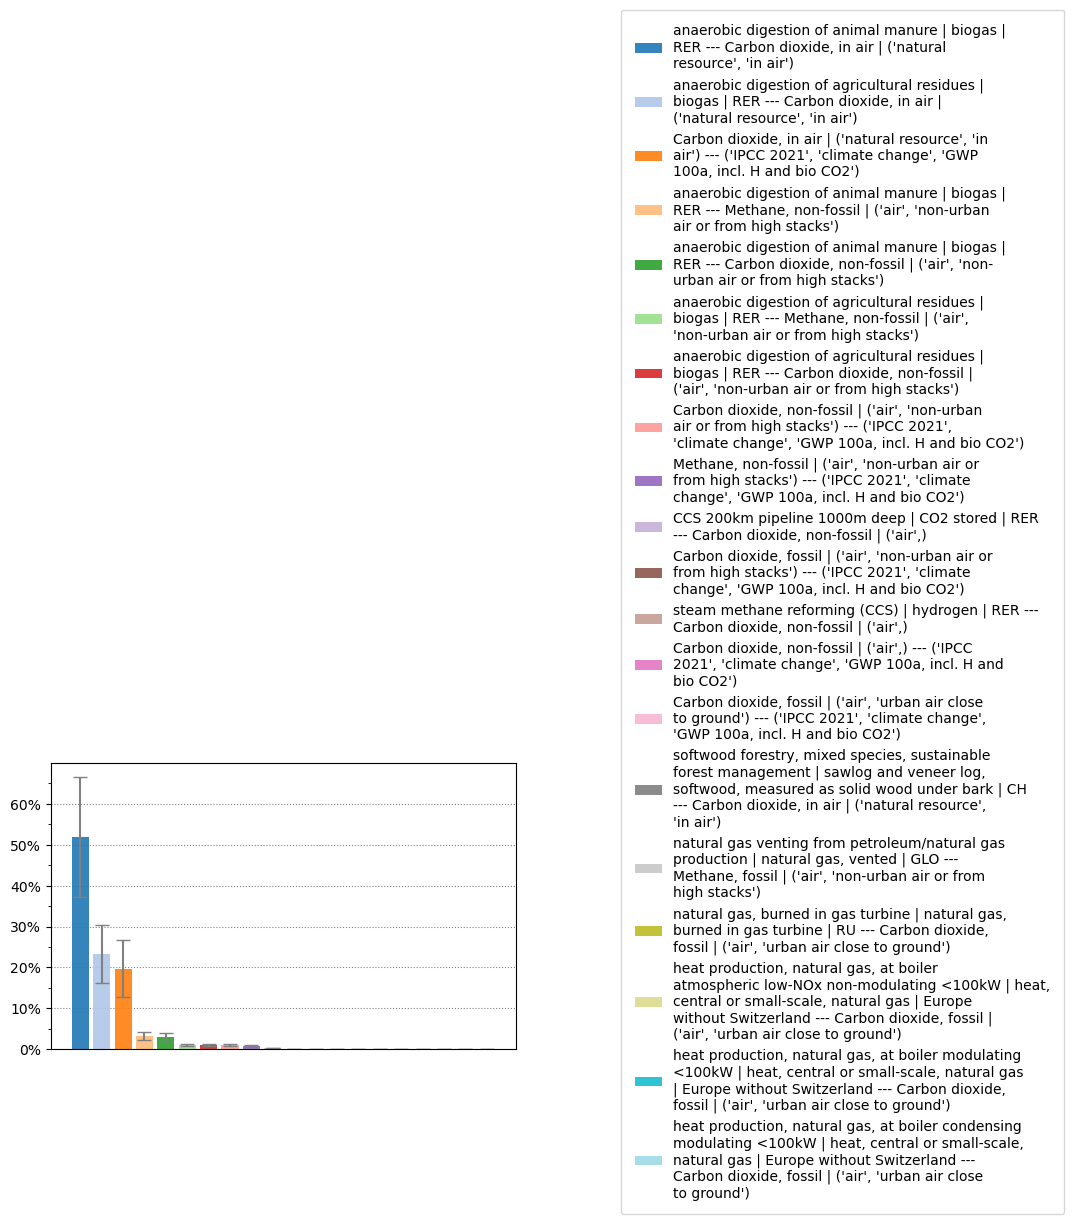

In [239]:
from SALib.sample import sobol as sample_method
from SALib.analyze import sobol as SA_method
pulpo_worker_gsa.run_gsa(
    result_data=results_CC_it1[0.5],
    sample_method=sample_method,
    SA_method=SA_method,
    sample_size=100,
    plot_gsa_results=True,
    top_sensitivity_amt=20
)

For all Pareto Points

In [ ]:
from SALib.sample import sobol as sample_method
from SALib.analyze import sobol as SA_method
for lambda_level, results_CC_level in results_CC_it1.items():
    print(f'Running GSA for lambda = {lambda_level}')
    pulpo_worker_gsa.import_and_filter_uncertainty_data(
        cutoff=0.000019, # removes processes to 1% impact contribution loss
        scaling_vector_strategy='naive',
        result_data=results_CC_level,
        plot_results=False,
        plot_n_top_processes=19
    )
    pulpo_worker_gsa.apply_uncertainty_strategies(strategies=unc_strategies)
    pulpo_worker_gsa.run_gsa(
        result_data=results_CC_level,
        sample_method=sample_method,
        SA_method=SA_method,
        sample_size=10,
        plot_gsa_results=True
    )

#### 2.4.1. Analysis outcome of GSA

The main contributing parameters are:

- the intervention flow Carbon Dioxide in air (natural resource) from:
    - anaerobic digestion of animal manure 
    - anaerobic digestion of agricultural residues
- the characterization factor for Carbon Dioxide in air (natural resource) in GWP100
- the intervention flow Carbon Dioxide from CCS


## Rest



### Ammonia production
- No end of life of ammonia is considered, though the majority of the impact of ammonia as with other chemicals are in the use and end-of-life of the chemical. As well as the societal relevance is deeply linked to tha application and therefore the allocation of limit or burdens.
- Technological lock-ins with centralized Haber Bosch processes, risks due to high dependency
- Rebound effects: If novel NH3 production processes are introduced it could just lead to a new product "green ammonia" being used in new sectors not substituting essential activites but creating new products or services or increasing their amount.


## X. Ontological uncertainty

- End-of-life processes not considered in the formulation  
- By extracting even more nutrients from the soil and the area by also completely using all residues etc. leads to more linear production systems quicker soil degredation which in turn requires more intensive production methods, e.g., more fertilizer or more land-use

